# ex02_lti_four_fir
Interactive notebook version of the Python example.
Edit parameters and rerun cells to explore the model behavior.

## MATLAB Example Structure
- The fourth-order LTI model without process noise
- Open-loop identification experiment
- Identification of the model in open loop
- Verification results
- Identification results
- Closed-loop identification experiment
- Identification of the model in closed loop
- Verification results
- Identification results

## Imports

In [22]:
from __future__ import annotations
import numpy as np
from _common import (
    estimate_fir_abcd,
    estimate_varx_abcdk,
    format_metric,
    print_case_summary,
    vaf_percent,
)
from control import matlab as ml
from pbsid.plotting import plot_bode_magnitude_grid, plot_pole_map, plot_singular_values
from snr import snr_db

## The Fourth-Order LTI Model Without Process Noise
State-space definition together with the MATLAB-style open-loop and closed-loop systems.

In [23]:
a = np.array(
    [
        [0.67, 0.67, 0.0, 0.0],
        [-0.67, 0.67, 0.0, 0.0],
        [0.0, 0.0, -0.67, -0.67],
        [0.0, 0.0, 0.67, -0.67],
    ],
    dtype=np.float64,
)
b = np.array(
    [[0.6598, -0.5256], [1.9698, 0.4845], [4.3171, -0.4879], [-2.6436, -0.3416]],
    dtype=np.float64,
)
c = np.array(
    [[-0.3749, 0.0751, -0.5225, 0.583], [-0.8977, 0.7543, 0.1159, 0.0982]],
    dtype=np.float64,
)
d = np.zeros((2, 2), dtype=np.float64)

## Open-Loop Identification Experiment
Simulate the open-loop experiment and compute the open-loop SNR.

In [24]:
n_samples = 4000
t = np.arange(n_samples, dtype=np.float64)
rng = np.random.default_rng(102)
r = rng.standard_normal((n_samples, 2))
e = rng.standard_normal((n_samples, 2))
ol = ml.ss(a, b, c, d, 1.0)
y0, _, _ = ml.lsim(ol, r, t)
y0 = np.asarray(y0, dtype=np.float64)
y = y0 + e
print("Signal to noise ratio (SNR) (open-loop)")
print(f"{format_metric(snr_db(y, y0))} dB")

Signal to noise ratio (SNR) (open-loop)
[19.17 15.14] dB


## Identification Of The Model In Open Loop
Estimate FIR and VARX models for the open-loop data.

In [25]:
n = 4
f = 10
p = 20
s_fir, ai, bi, ci, di = estimate_fir_abcd(r, y, n, f, p)
s_varx, av, bv, cv, dv, _, _, _ = estimate_varx_abcdk(r, y, n, f, p)

## Verification Results
Open-loop verification against the identified models.

In [26]:
yi, _, _ = ml.lsim(ml.ss(ai, bi, ci, di, 1.0), r, t)
yv, _, _ = ml.lsim(ml.ss(av, bv, cv, dv, 1.0), r, t)
yi = np.asarray(yi, dtype=np.float64)
yv = np.asarray(yv, dtype=np.float64)
print_case_summary("ex02-open-fir", snr_db(y, y0), vaf_percent(y0, yi), ai)
print_case_summary("ex02-open-varx", snr_db(y, y0), vaf_percent(y0, yv), av)


[ex02-open-fir]
SNR (dB): [19.17 15.14]
VAF (%): [95.69 96.76]
Estimated poles: [-0.6474+0.6658j -0.6474-0.6658j  0.6608+0.6566j  0.6608-0.6566j]

[ex02-open-varx]
SNR (dB): [19.17 15.14]
VAF (%): [99.94 99.88]
Estimated poles: [-0.6698+0.6689j -0.6698-0.6689j  0.6706+0.6696j  0.6706-0.6696j]


## Identification Results
MATLAB plots poles and bode diagrams here. The notebook currently reports the identified poles through `print_case_summary`.

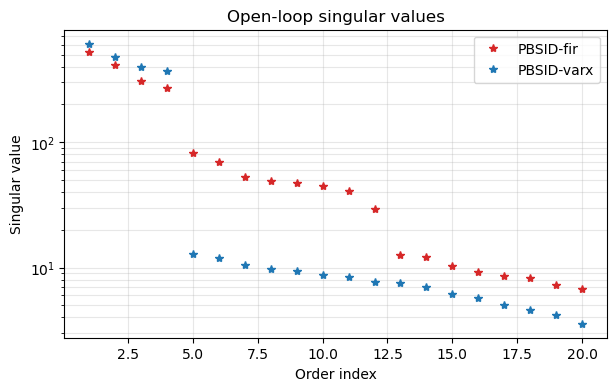

In [40]:
plot_singular_values(
    [
        (s_fir, "PBSID-fir", "r*", "tab:red"),
        (s_varx, "PBSID-varx", "b*", "tab:blue"),
    ],
    "Open-loop singular values",
)


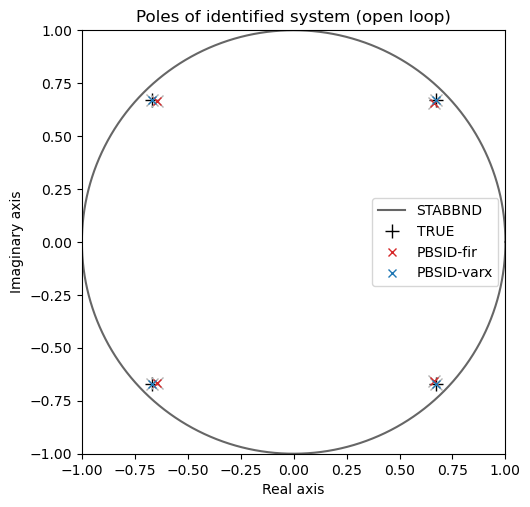

In [41]:

plot_pole_map(
    np.linalg.eigvals(a),
    [
        ("PBSID-fir", np.linalg.eigvals(ai), "x", "tab:red"),
        ("PBSID-varx", np.linalg.eigvals(av), "x", "tab:blue"),
    ],
    "Poles of identified system (open loop)",
)


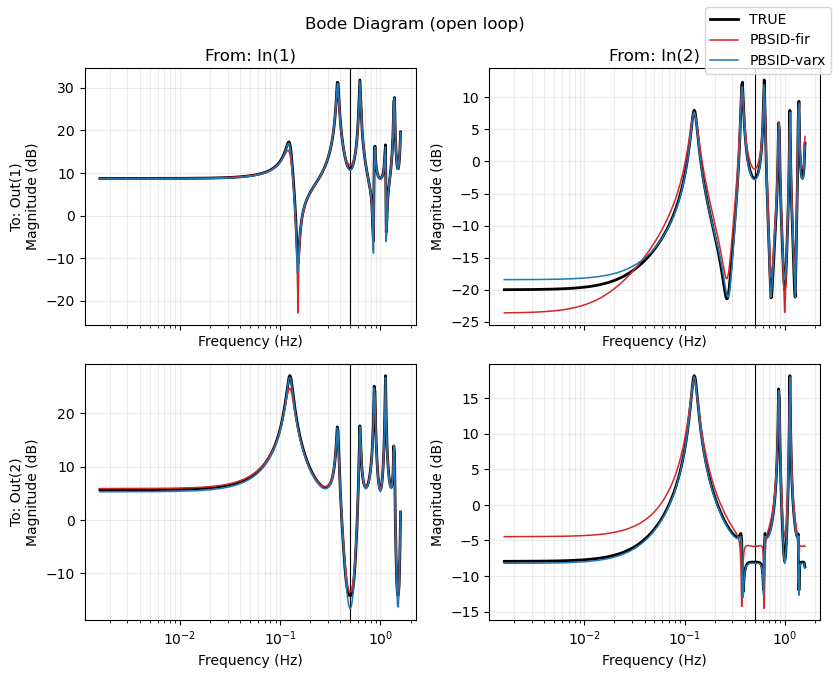

In [42]:

plot_bode_magnitude_grid(
    ml.ss(a, b, c, d, 1.0),
    [
        ("PBSID-fir", ml.ss(ai, bi, ci, di, 1.0), "tab:red"),
        ("PBSID-varx", ml.ss(av, bv, cv, dv, 1.0), "tab:blue"),
    ],
    "Bode Diagram (open loop)",
)

## Closed-Loop Identification Experiment
Simulate the closed-loop experiment and compute the closed-loop SNR.

In [28]:
f_gain = np.diag([0.25, 0.25]).astype(np.float64)
cl = ml.feedback(ol, ml.ss([], [], [], f_gain, 1.0), sign=-1)
y_cl_nom, _, _ = ml.lsim(cl, r, t)
y_cl_nom = np.asarray(y_cl_nom, dtype=np.float64)
y_cl = y_cl_nom + 0.5 * e
u_cl = r - y_cl @ f_gain.T
y0_cl, _, _ = ml.lsim(ol, u_cl, t)
y0_cl = np.asarray(y0_cl, dtype=np.float64)
print("Signal to noise ratio (SNR) (closed-loop)")
print(f"{format_metric(snr_db(y_cl, y0_cl))} dB")

Signal to noise ratio (SNR) (closed-loop)
[12.73 15.39] dB


## Identification Of The Model In Closed Loop
Estimate FIR and VARX models for the closed-loop data.

In [29]:
s_fir_cl, ai_cl, bi_cl, ci_cl, di_cl = estimate_fir_abcd(u_cl, y_cl, n, f, p)
s_varx_cl, av_cl, bv_cl, cv_cl, dv_cl, _, _, _ = estimate_varx_abcdk(u_cl, y_cl, n, f, p)

## Verification Results
Closed-loop verification against the identified models.

In [30]:
yi_cl, _, _ = ml.lsim(ml.ss(ai_cl, bi_cl, ci_cl, di_cl, 1.0), u_cl, t)
yv_cl, _, _ = ml.lsim(ml.ss(av_cl, bv_cl, cv_cl, dv_cl, 1.0), u_cl, t)
yi_cl = np.asarray(yi_cl, dtype=np.float64)
yv_cl = np.asarray(yv_cl, dtype=np.float64)
print_case_summary(
    "ex02-closed-fir", snr_db(y_cl, y0_cl), vaf_percent(y0_cl, yi_cl), ai_cl
)
print_case_summary(
    "ex02-closed-varx", snr_db(y_cl, y0_cl), vaf_percent(y0_cl, yv_cl), av_cl
)


[ex02-closed-fir]
SNR (dB): [12.73 15.39]
VAF (%): [89.87 94.06]
Estimated poles: [ 0.5689+0.5799j  0.5689-0.5799j -0.4571+0.6289j -0.4571-0.6289j]

[ex02-closed-varx]
SNR (dB): [12.73 15.39]
VAF (%): [99.64 99.65]
Estimated poles: [ 0.6589+0.6605j  0.6589-0.6605j -0.6567+0.6627j -0.6567-0.6627j]


## Identification Results
MATLAB plots poles and bode diagrams here as well; those plotting helpers are still pending for a closer visual match.

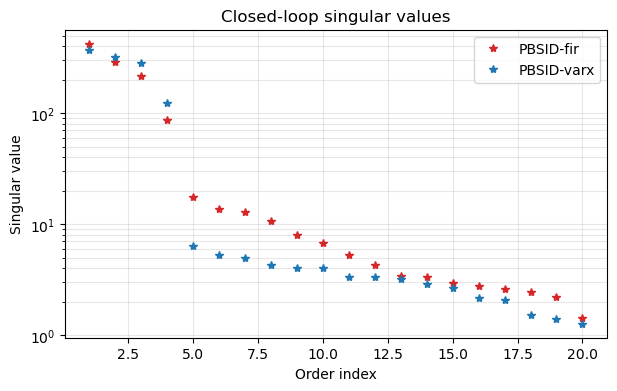

In [39]:
plot_singular_values(
    [
        (s_fir_cl, "PBSID-fir", "r*", "tab:red"),
        (s_varx_cl, "PBSID-varx", "b*", "tab:blue"),
    ],
    "Closed-loop singular values",
)

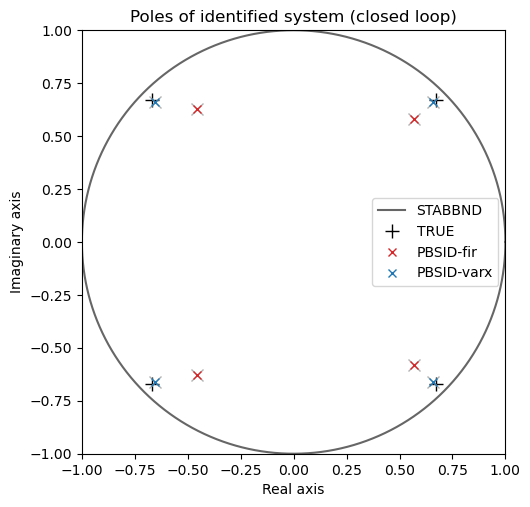

In [32]:

plot_pole_map(
    np.linalg.eigvals(a),
    [
        ("PBSID-fir", np.linalg.eigvals(ai_cl), "x", "tab:red"),
        ("PBSID-varx", np.linalg.eigvals(av_cl), "x", "tab:blue"),
    ],
    "Poles of identified system (closed loop)",
)

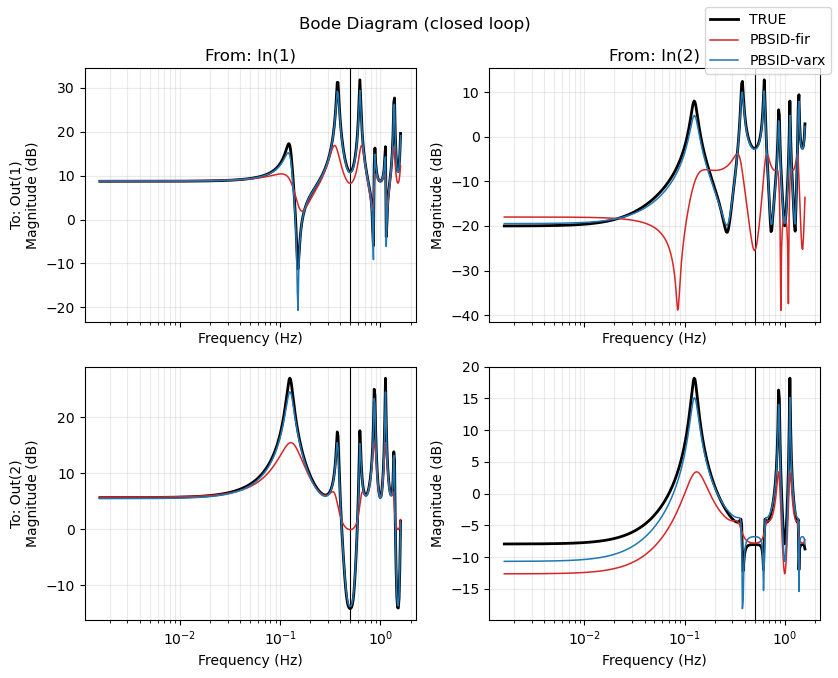

In [33]:

plot_bode_magnitude_grid(
    ml.ss(a, b, c, d, 1.0),
    [
        ("PBSID-fir", ml.ss(ai_cl, bi_cl, ci_cl, di_cl, 1.0), "tab:red"),
        ("PBSID-varx", ml.ss(av_cl, bv_cl, cv_cl, dv_cl, 1.0), "tab:blue"),
    ],
    "Bode Diagram (closed loop)",
)